In [59]:
import pandas as pd
import matplotlib.pyplot as plt

In [60]:
df = pd.read_csv("../data/raw/car_raw_details.csv")

In [61]:
df.isnull().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

In [62]:
df.columns

Index(['Make', 'Model', 'Price', 'Year', 'Kilometer', 'Fuel Type',
       'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine',
       'Max Power', 'Max Torque', 'Drivetrain', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity'],
      dtype='str')

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   str    
 1   Model               2059 non-null   str    
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   str    
 6   Transmission        2059 non-null   str    
 7   Location            2059 non-null   str    
 8   Color               2059 non-null   str    
 9   Owner               2059 non-null   str    
 10  Seller Type         2059 non-null   str    
 11  Engine              1979 non-null   str    
 12  Max Power           1979 non-null   str    
 13  Max Torque          1979 non-null   str    
 14  Drivetrain          1923 non-null   str    
 15  Length              1995 non-null   float64
 16  Width            

In [64]:
df["Engine"].unique()

<StringArray>
['1198 cc', '1248 cc', '1197 cc', '2393 cc', '1373 cc', '1991 cc', '1995 cc',
 '1798 cc', '1461 cc',  '999 cc',
 ...
 '2998 cc', '2198 cc', '2157 cc', '1595 cc', '1586 cc',  '936 cc', '1332 cc',
 '2400 cc',  '793 cc',  '995 cc']
Length: 109, dtype: str

In [65]:
# Columns containing numerical values with possible units
numeric_cols = [
    "Engine",
    "Max Power",
    "Max Torque",
    "Length",
    "Width",
    "Height",
    "Seating Capacity",
    "Fuel Tank Capacity",
    "Engine",
    "Max Power",
    "Max Torque"
]

# Extract the first numeric value from each column
for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col].astype("string").str.extract(r"([-+]?\d*\.?\d+)")[0],
        errors="coerce"
    )
df.to_csv("../data/processed/car_new_details.csv",index=False)

# Check the result
print(df[numeric_cols].head())

   Engine  Max Power  Max Torque  Length   Width  Height  Seating Capacity  \
0    1198       87.0       109.0  3990.0  1680.0  1505.0               5.0   
1    1248       74.0       190.0  3995.0  1695.0  1555.0               5.0   
2    1197       79.0    112.7619  3585.0  1595.0  1550.0               5.0   
3    1197       82.0       113.0  3995.0  1745.0  1510.0               5.0   
4    2393      148.0       343.0  4735.0  1830.0  1795.0               7.0   

   Fuel Tank Capacity  Engine  Max Power  Max Torque  
0                35.0    1198       87.0       109.0  
1                42.0    1248       74.0       190.0  
2                35.0    1197       79.0    112.7619  
3                37.0    1197       82.0       113.0  
4                55.0    2393      148.0       343.0  


In [66]:
numeric_columns = df.select_dtypes(include="number").columns
print(numeric_columns)

Index(['Price', 'Year', 'Kilometer', 'Engine', 'Max Power', 'Max Torque',
       'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity'],
      dtype='str')


In [67]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Price,2059.0,1702991.696455,2419880.635434,49000.0,484999.0,825000.0,1925000.0,35000000.0
Year,2059.0,2016.425449,3.363564,1988.0,2014.0,2017.0,2019.0,2022.0
Kilometer,2059.0,54224.714424,57361.721314,0.0,29000.0,50000.0,72000.0,2000000.0
Engine,1979.0,1692.575543,643.736294,624.0,1197.0,1498.0,1995.0,6592.0
Max Power,1979.0,129.611774,65.073797,35.0,83.0,116.0,171.0,660.0
Max Torque,1979.0,245.851019,140.465731,48.0,115.0,200.0,350.0,780.0
Length,1995.0,4280.860652,442.458507,3099.0,3985.0,4370.0,4629.0,5569.0
Width,1995.0,1767.99198,135.265825,1475.0,1695.0,1770.0,1831.5,2220.0
Height,1995.0,1591.735338,136.073956,1165.0,1485.0,1545.0,1675.0,1995.0
Seating Capacity,1995.0,5.306266,0.82217,2.0,5.0,5.0,5.0,8.0


In [68]:
skewness = df[numeric_columns].skew()

skewness_df = pd.DataFrame({
    "Skewness": skewness,
    "Absolute Skewness": skewness.abs()
}).sort_values("Absolute Skewness", ascending=False)

skewness_df

,Skewness,Absolute Skewness
Kilometer,20.980719,20.980719
Price,4.965143,4.965143
Max Power,2.071205,2.071205
Engine,1.75506,1.75506
Seating Capacity,1.468083,1.468083
Max Torque,0.880474,0.880474
Fuel Tank Capacity,0.853003,0.853003
Year,-0.840685,0.840685
Height,0.83778,0.83778
Width,0.308335,0.308335


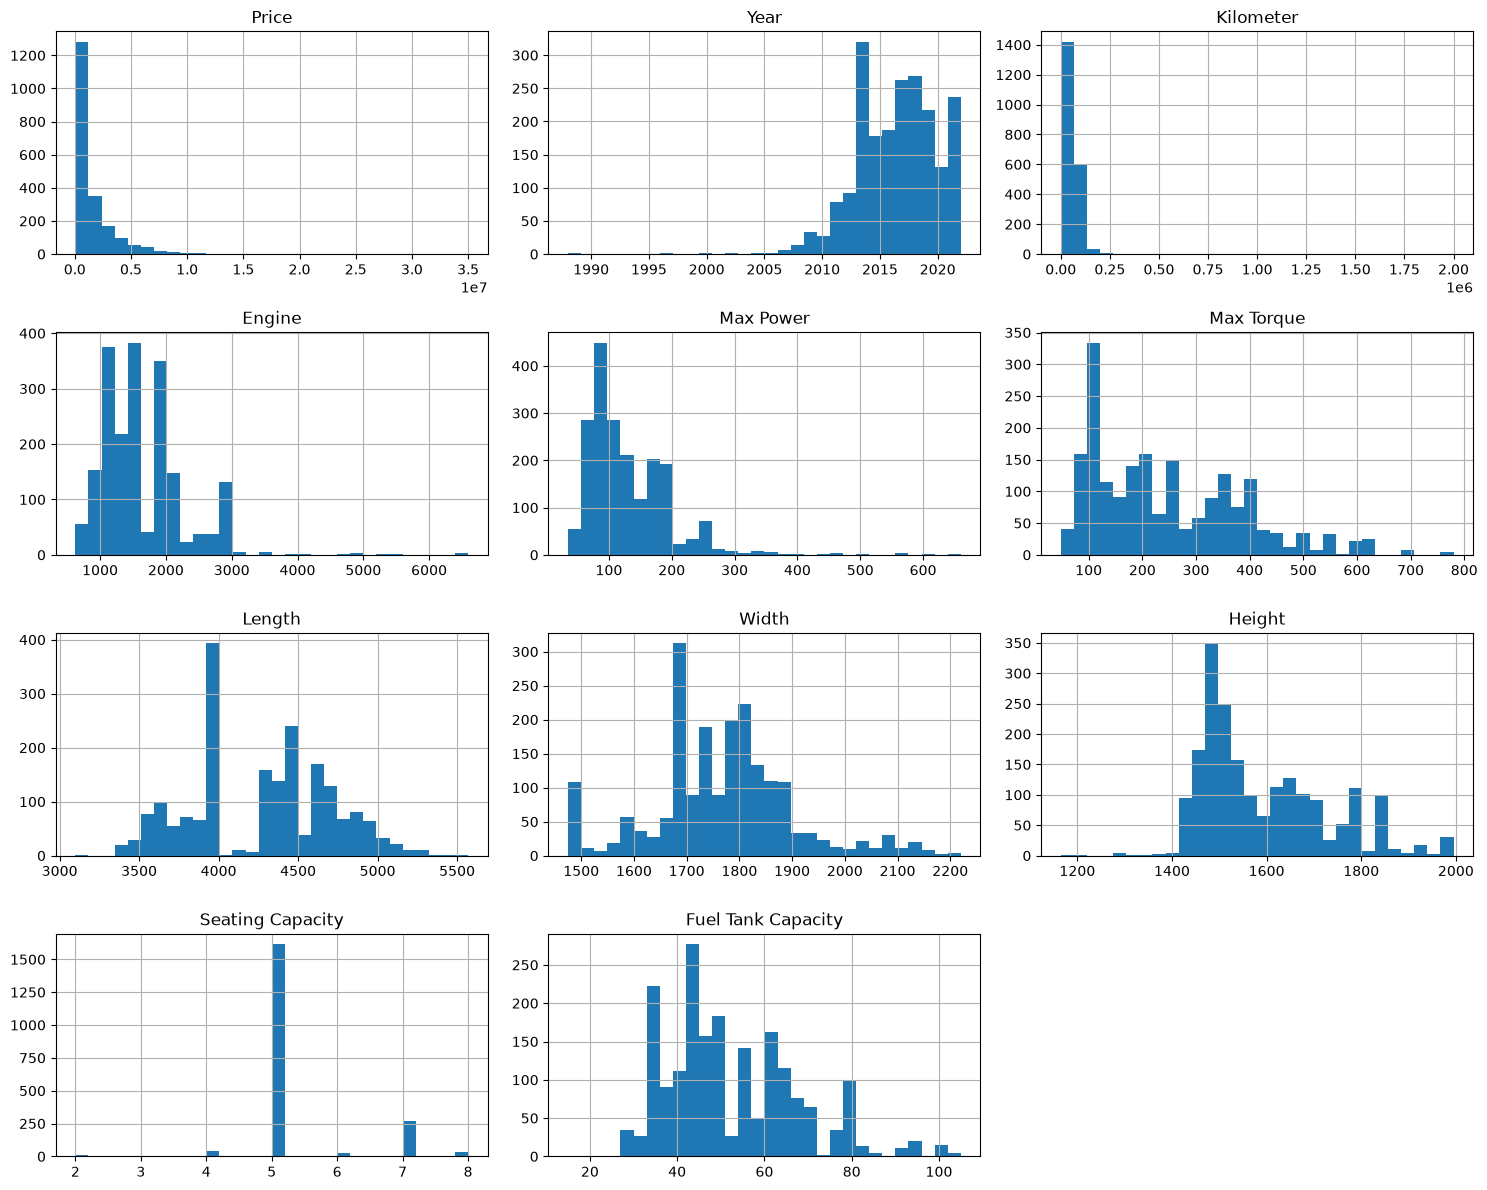

In [69]:
df[numeric_columns].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

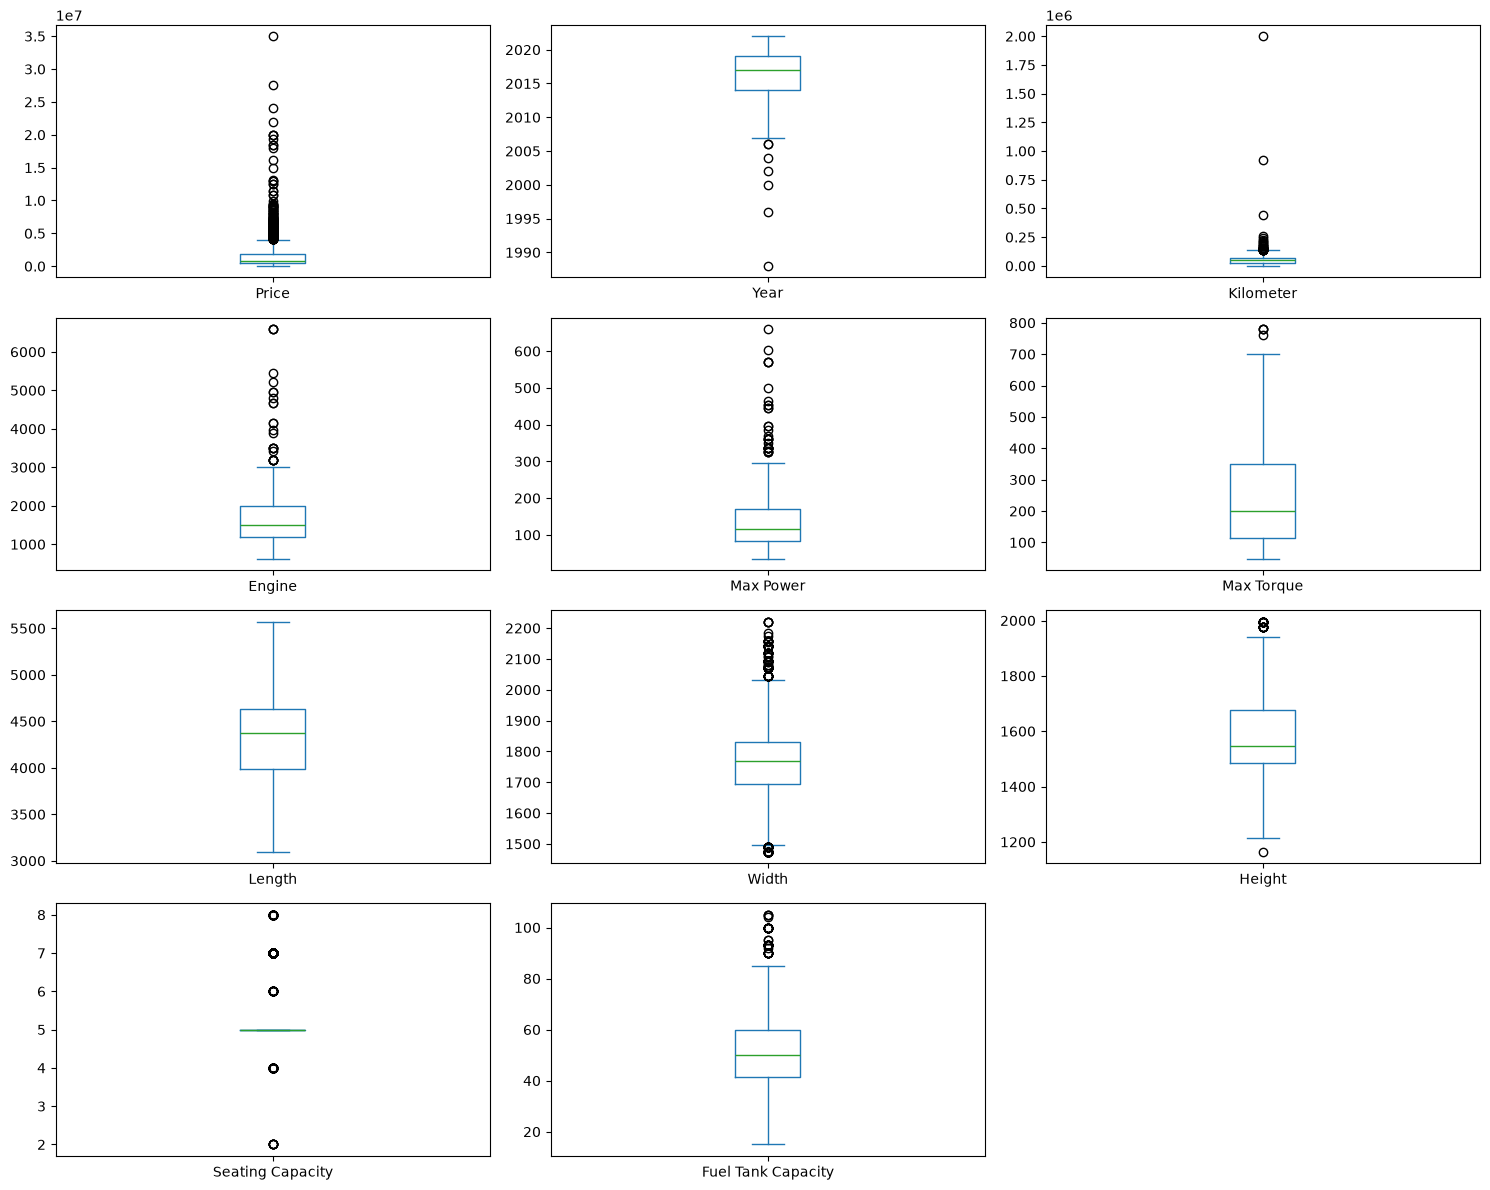

In [70]:
df[numeric_columns].plot(
    kind="box",
    subplots=True,
    layout=(4, 3),
    figsize=(15, 12)
)

plt.tight_layout()
plt.show()

In [71]:
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [72]:
outlier_counts = (
    ((df[numeric_columns] < lower_bound) |
     (df[numeric_columns] > upper_bound))
    .sum()
    .sort_values(ascending=False)
)

outlier_counts

Seating Capacity      380
Price                 215
Width                 182
Fuel Tank Capacity     50
Kilometer              36
Max Power              31
Height                 31
Engine                 25
Year                    7
Max Torque              4
Length                  0
dtype: Int64

In [73]:
# Show the most extreme values for important numerical features

features_to_check = [
    "Price",
    "Kilometer",
    "Engine",
    "Max Power",
    "Max Torque",
    "Width",
    "Height",
    "Fuel Tank Capacity",
    "Year"
]

for col in features_to_check:
    print(f"\n--- {col} ---")
    print(df[col].sort_values(ascending=False).head(10))


--- Price ---
483     35000000
1305    27500000
510     24000000
582     22000000
1369    20000000
1246    20000000
1890    20000000
1313    19300000
1912    18500000
442     18500000
Name: Price, dtype: int64

--- Kilometer ---
1125    2000000
1866     925000
1515     440000
1992     261236
733      240000
1628     222000
1991     219000
181      211000
134      195000
388      192326
Name: Kilometer, dtype: int64

--- Engine ---
977     6592
1369    6592
1246    6592
575     5461
510     5204
1035    4951
1724    4951
235     4806
1768    4663
160     4663
Name: Engine, dtype: Int64

--- Max Power ---
483     660.0
510     602.0
977     570.0
1369    570.0
1246    570.0
235     500.0
442     463.0
160     453.0
1768    453.0
214     444.0
Name: Max Power, dtype: Float64

--- Max Torque ---
977     780.0
1369    780.0
1246    780.0
483     760.0
442     700.0
1370    700.0
160     700.0
235     700.0
542     700.0
1768    700.0
Name: Max Torque, dtype: Float64

--- Width ---
582     

In [74]:
df.loc[df["Kilometer"].nlargest(10).index,
       ["Make", "Model", "Year", "Kilometer", "Price"]]

,Make,Model,Year,Kilometer,Price
1125,Renault,Duster 110 PS RXZ 4X2 MT Diesel,2016,2000000,450000
1866,Hyundai,Verna 1.6 CRDI SX,2018,925000,925000
1515,Hyundai,Creta SX 1.6 AT CRDi,2018,440000,1240000
1992,Toyota,Innova 2.0 G1 BS-IV,2010,261236,555000
733,Audi,A6 3.0 TDI quattro Premium,2012,240000,1650000
1628,Toyota,Innova 2.5 V 7 STR,2012,222000,960000
1991,Toyota,Fortuner 2.8 4x4 AT [2016-2020],2017,219000,2750000
181,Toyota,Fortuner 3.0 4x4 MT,2014,211000,1675000
134,BMW,5-Series 520d Sedan,2013,195000,1490000
388,Tata,Grande GX,2011,192326,199000


In [75]:
df.loc[df["Engine"].nlargest(10).index,
       ["Make", "Model", "Year", "Engine", "Price"]]

,Make,Model,Year,Engine,Price
977,Rolls-Royce,Ghost 6.5,2011,6592,18000000
1246,Rolls-Royce,Ghost Extended Wheelbase,2011,6592,20000000
1369,Rolls-Royce,Ghost Extended Wheelbase,2012,6592,20000000
575,Mercedes-Benz,S-Class 500L,2012,5461,1650000
510,Lamborghini,Huracan LP 610-4,2016,5204,24000000
1035,Ford,Mustang GT Fastback 5.0L v8,2017,4951,8000000
1724,Ford,Mustang GT Fastback 5.0L v8,2018,4951,7990000
235,Porsche,Cayenne Turbo,2014,4806,3500000
160,Mercedes-Benz,S-Class Maybach S 500,2016,4663,11500000
1768,Mercedes-Benz,S-Class S 500,2011,4663,1875000


In [76]:
df.loc[df["Max Power"].nlargest(10).index,
       ["Make", "Model", "Year", "Max Power", "Price"]]

,Make,Model,Year,Max Power,Price
483,Ferrari,488 GTB,2018,660.0,35000000
510,Lamborghini,Huracan LP 610-4,2016,602.0,24000000
977,Rolls-Royce,Ghost 6.5,2011,570.0,18000000
1246,Rolls-Royce,Ghost Extended Wheelbase,2011,570.0,20000000
1369,Rolls-Royce,Ghost Extended Wheelbase,2012,570.0,20000000
235,Porsche,Cayenne Turbo,2014,500.0,3500000
442,Mercedes-Benz,S-Class Maybach S 560,2021,463.0,18500000
160,Mercedes-Benz,S-Class Maybach S 500,2016,453.0,11500000
1768,Mercedes-Benz,S-Class S 500,2011,453.0,1875000
214,Audi,RS5 4.2 Coupe,2012,444.0,3650000


In [77]:
df.loc[df["Price"].nlargest(10).index,
       ["Make", "Model", "Year", "Price"]]

,Make,Model,Year,Price
483,Ferrari,488 GTB,2018,35000000
1305,Land Rover,Range Rover 3.0 V6 Diesel Vogue LWB,2020,27500000
510,Lamborghini,Huracan LP 610-4,2016,24000000
582,Land Rover,Range Rover 3.0 V6 Diesel Vogue,2019,22000000
1246,Rolls-Royce,Ghost Extended Wheelbase,2011,20000000
1369,Rolls-Royce,Ghost Extended Wheelbase,2012,20000000
1890,Mercedes-Benz,S-Class S 450,2021,20000000
1313,Land Rover,Range Rover 3.0 V6 Diesel Vogue,2019,19300000
442,Mercedes-Benz,S-Class Maybach S 560,2021,18500000
1912,Mercedes-Benz,S-Class S 350D [2018-2020],2021,18500000


In [78]:
df["Seating Capacity"].value_counts().sort_index()

Seating Capacity
2.0       7
4.0      42
5.0    1615
6.0      23
7.0     273
8.0      35
Name: count, dtype: Int64

In [79]:
df.isnull().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

In [80]:
df["Engine"] = df["Engine"].fillna(df["Engine"].median())

df["Max Power"] = df["Max Power"].fillna(df["Max Power"].median())

df["Max Torque"] = df["Max Torque"].fillna(df["Max Torque"].median())

df["Length"] = df["Length"].fillna(df["Length"].median())

df["Width"] = df["Width"].fillna(df["Width"].median())

df["Height"] = df["Height"].fillna(df["Height"].median())

df["Seating Capacity"] = df["Seating Capacity"].fillna(
    df["Seating Capacity"].mode()[0]
)

df["Fuel Tank Capacity"] = df["Fuel Tank Capacity"].fillna(
    df["Fuel Tank Capacity"].median()
)

df["Drivetrain"] = df["Drivetrain"].fillna("Unknown")

In [81]:
df = df[~df["Kilometer"].isin([2000000, 925000])].copy()

In [82]:
df.shape

(2057, 20)

In [83]:
df["Kilometer"].nlargest(10)

1515    440000
1992    261236
733     240000
1628    222000
1991    219000
181     211000
134     195000
388     192326
706     185000
2021    173000
Name: Kilometer, dtype: int64

In [84]:
df.to_csv(
    "../data/processed/car_new_details.csv",
    index=False
)

In [85]:
df.isna().sum()

Make                  0
Model                 0
Price                 0
Year                  0
Kilometer             0
Fuel Type             0
Transmission          0
Location              0
Color                 0
Owner                 0
Seller Type           0
Engine                0
Max Power             0
Max Torque            0
Drivetrain            0
Length                0
Width                 0
Height                0
Seating Capacity      0
Fuel Tank Capacity    0
dtype: int64

In [86]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Make ---
Make
Maruti Suzuki    440
Hyundai          348
Mercedes-Benz    171
Honda            158
Toyota           132
Audi             127
BMW              121
Mahindra         119
Tata              57
Volkswagen        50
Ford              48
Renault           42
Skoda             40
Land Rover        33
Kia               23
Jeep              18
MG                17
Jaguar            17
Nissan            16
Volvo             16
Porsche           15
MINI              11
Datsun             8
Chevrolet          7
Lexus              6
Mitsubishi         4
Ssangyong          3
Rolls-Royce        3
Isuzu              2
Fiat               2
Maserati           1
Ferrari            1
Lamborghini        1
Name: count, dtype: int64

--- Model ---
Model
X1 sDrive20d xLine                     15
Swift DZire VDI                        14
Fortuner 2.8 4x2 AT [2016-2020]        13
City V                                 13
Swift DZire VXI                        12
                               

In [87]:
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

Make: 33 unique values
Model: 1049 unique values
Fuel Type: 9 unique values
Transmission: 2 unique values
Location: 77 unique values
Color: 17 unique values
Owner: 6 unique values
Seller Type: 3 unique values
Drivetrain: 4 unique values
